In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install pvlib

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 54.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import StandardScaler

class MPPTDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1) # [Batch, 1] 형태로 변경

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

def preprocess_data(file_path, scaler=None):
    data = np.load(file_path)
    X, Y = data['X'], data['Y']

    # 1. Day (인덱스 4) 변환: 0 ~ 1 ~ 0
    day = X[:, :, 4]
    X[:, :, 4] = np.sin(np.pi * day / 365.0)

    # 2. Hour (인덱스 5) 변환: 1 ~ 0 ~ -1
    hour = X[:, :, 5]
    X[:, :, 5] = np.cos(np.pi * (hour - 5.0) / 14.0)

    # 3. V, I, P, dP/dV (인덱스 0~3) 스케일링
    batch, seq_len, features = X.shape
    X_reshaped = X.reshape(-1, features)

    if scaler is None:
        scaler = StandardScaler()
        X_reshaped[:, :4] = scaler.fit_transform(X_reshaped[:, :4])
    else:
        X_reshaped[:, :4] = scaler.transform(X_reshaped[:, :4])

    X_scaled = X_reshaped.reshape(batch, seq_len, features)

    return X_scaled, Y, scaler

In [3]:
class MPPTTriggerLSTM(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2):
        super(MPPTTriggerLSTM, self).__init__()

        # LSTM 계층
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True, # 입력 형태: [Batch, Seq, Feature]
            dropout=0.4 if num_layers > 1 else 0
        )

        # 완전 연결 계층 (분류기)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, 1) # 이진 분류이므로 출력 노드는 1개
        )

    def forward(self, x):
        # out: 모든 time step의 hidden state
        # hn: 마지막 time step의 hidden state
        out, (hn, cn) = self.lstm(x)

        # 마지막 윈도우 스텝(60번째 초)의 결과값만 사용
        last_hidden = out[:, -1, :]

        logits = self.fc(last_hidden)
        return logits # 손실 함수에서 Sigmoid를 처리하도록 설계 (BCEWithLogitsLoss)

In [4]:
import torch
import numpy as np
from torch.utils.data import DataLoader

# 1. GPU 장치 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"평가에 사용할 장치: {device}")

# 2. 테스트 데이터셋 전처리 및 로드
file_path = '/content/drive/MyDrive/mppt_dataset/mppt_thesis_dataset_1year_2.npz'
# 학습 때 사용했던 scaler가 메모리에 살아있어야 합니다.

train_path = '/content/drive/MyDrive/mppt_dataset/mppt_thesis_dataset_merged.npz'
test_path = '/content/drive/MyDrive/mppt_dataset/mppt_thesis_dataset_1year_1.npz'

print("데이터 전처리 중...")
X_train, Y_train, scaler = preprocess_data(train_path)
X_test, Y_test, _ = preprocess_data(test_path, scaler=scaler) # 테스트 데이터는 훈련 스케일러 적용

train_dataset = MPPTDataset(X_train, Y_train)
test_dataset = MPPTDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

x_test_np, y_test_np, _ = preprocess_data(file_path, scaler=scaler)

# 🌟 수정 포인트: 직접 만드신 MPPTDataset 재사용 (차원 자동 맞춤 기능 활용)
test_dataset = MPPTDataset(x_test_np, y_test_np)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3. 모델 인스턴스화 및 가중치 로드
model = MPPTTriggerLSTM(input_size=6, hidden_size=64, num_layers=2).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/mppt_dataset/mppt_lstm_model.pth', map_location=device))
model.eval()

# 4. 테스트 진행 및 정답률 계산
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device) # MPPTDataset 덕분에 [Batch, 1] 형태로 들어옴

        outputs = model(inputs)

        # 🌟 수정 포인트: 학습 루프와 동일한 이진 분류 로직 적용
        predicted = (outputs > 0).float()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 최종 정확도 계산
accuracy = 100 * correct / total

print(f'\n--- 평가 결과 ---')
print(f'총 데이터 수: {total}개')
print(f'맞춘 문제 수: {correct}개')
print(f'모델 정답률(Accuracy): {accuracy:.2f}%')

평가에 사용할 장치: cpu
데이터 전처리 중...

--- 평가 결과 ---
총 데이터 수: 2023개
맞춘 문제 수: 2022개
모델 정답률(Accuracy): 99.95%


In [12]:
import numpy as np
import pandas as pd
import pvlib
from pvlib.location import Location
from tqdm import tqdm
import os
np.random.seed(1045)

# ==========================================
# [Step 1] 기본 시스템 및 위치 설정
# ==========================================
LATITUDE = 37.5665
LONGITUDE = 126.9780
TZ = 'Asia/Seoul'
site_location = Location(LATITUDE, LONGITUDE, tz=TZ, name='Seoul')

START_HOUR = 5
END_HOUR = 19
NUM_MODULES = 10
WINDOW_SIZE = 60
NOCT_INSTALLED = 43.0

cec_modules = pvlib.pvsystem.retrieve_sam('cecmod')
MODULE_DATA = cec_modules['Hanwha_Q_Cells_Q_PEAK_DUO_L_G5_2_390']

# ==========================================
# [Step 2] 구름 이벤트 클래스 (최종 수정본)
# ==========================================
class CloudEvent:
    def __init__(self):
        self.active = False
        self.start_t = 0
        self.duration = 0
        self.intensity = 0
        self.velocity = 0.0
        self.width = 0.0
        self.event_type = 'moving'

    def trigger(self, t):
        self.active = True
        self.start_t = t
        self.intensity = np.random.uniform(0.7, 0.95)

        if np.random.rand() < 0.5:
            self.event_type = 'moving'
            self.velocity = np.random.uniform(0.005, 0.01)
            self.width = np.random.uniform(2.0, 5.0)
            # moving의 경우 duration을 사용하지 않고 '위치'로 종료 판단
        else:
            self.event_type = 'uniform'
            self.duration = np.random.randint(300, 1200) # uniform일 때만 duration 사용
            self.velocity = 0.0
            self.width = 0.0

    def get_shading_factors(self, t):
        if not self.active: return np.ones(NUM_MODULES)

        elapsed = t - self.start_t
        factors = np.ones(NUM_MODULES)

        if self.event_type == 'moving':
            # 1. 이동하는 구름
            # 구름의 중심 위치 계산 (시작점: 0번 패널 앞쪽(-width)에서 출발)
            center = (elapsed * self.velocity) - self.width

            # [핵심 수정] 구름의 꼬리까지 마지막 패널(NUM_MODULES)을 완전히 빠져나갔는지 확인 (2026/04/06)
            if center > (NUM_MODULES + self.width):
                self.active = False
                return np.ones(NUM_MODULES)

            # 구름이 아직 지나가는 중이라면 음영 계산
            for i in range(NUM_MODULES):
                dist = abs(i - center)
                if dist < self.width: # width 범위 내에 들어온 패널만 음영 적용
                    shading = self.intensity * np.exp(-(dist**2) / (2 * (self.width/2)**2))
                    factors[i] = 1 - shading

        elif self.event_type == 'uniform':
            # 2. 전체 패널 균일 흐려짐 (2026/04/06)
            # 설정된 duration(사인파 1주기)이 끝나면 종료
            if elapsed >= self.duration:
                self.active = False
                return np.ones(NUM_MODULES)

            shading = self.intensity * np.sin(np.pi * (elapsed / self.duration))
            factors *= (1 - shading)

        return factors

In [13]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm


def run_mppt_comparison(target_date, model, scaler, device='cpu', trigger_threshold=0.5):
    print(f"\n[{target_date}] MPPT 알고리즘 성능 비교 시뮬레이션 시작...")
    model.eval() # 모델을 평가 모드로 전환

    # =========================================================
    # 1. 환경 생성 (기존 simulate_single_day와 동일)
    # =========================================================
    start_time = f'{target_date} {START_HOUR:02d}:00:00'
    end_time = f'{target_date} {END_HOUR:02d}:00:00'
    times = pd.date_range(start=start_time, end=end_time, freq='s', tz=TZ)
    total_seconds = len(times)

    clearsky = site_location.get_clearsky(times)
    base_g_array = clearsky['ghi'].values

    G_matrix = np.zeros((total_seconds, NUM_MODULES))
    cloud = CloudEvent()
    cloud_type_array = np.zeros(total_seconds, dtype=int)

    for t in range(total_seconds):
        base_g = max(base_g_array[t], 20.0)
        if not cloud.active and np.random.rand() < (30 / total_seconds):
            cloud.trigger(t)
        factors = cloud.get_shading_factors(t)
        G_matrix[t, :] = base_g * factors

        if cloud.active:
            if cloud.event_type == 'moving':
                cloud_type_array[t] = 1
            elif cloud.event_type == 'uniform':
                cloud_type_array[t] = 2

    # 온도 계산
    T_matrix = np.zeros((total_seconds, NUM_MODULES))
    month = times[0].month
    temp_air_base = 15.0 - 15.0 * np.cos(np.pi * (month - 1) / 6.0)
    hours = times.hour + (times.minute / 60.0) + (times.second / 3600.0)
    temp_air_hourly = temp_air_base + 5.0 * np.sin(np.pi * (hours - 7.0) / 12.0)
    temp_air_series = pd.Series(temp_air_hourly, index=times)
    wind_speed_series = pd.Series(1.0, index=times)

    for i in range(NUM_MODULES):
        poa_series = pd.Series(G_matrix[:, i], index=times)
        t_cell = pvlib.temperature.fuentes(
            poa_global=poa_series, temp_air=temp_air_series,
            wind_speed=wind_speed_series, noct_installed=NOCT_INSTALLED
        )
        T_matrix[:, i] = t_cell.values

    # =========================================================
    # 2. 물리 엔진 사전 계산 (속도 최적화를 위해 한 번만 계산)
    # =========================================================
    true_v_arr = np.zeros(total_seconds)
    true_p_arr = np.zeros(total_seconds)
    v_clean_list = []
    i_clean_list = []

    for t in tqdm(range(total_seconds), desc="Physics Engine Pre-computing"):
        current_gs = G_matrix[t]
        current_ts = T_matrix[t]
        i_array = np.linspace(0, MODULE_DATA['I_sc_ref'] + 1, 300)
        v_total = np.zeros_like(i_array)

        for g, temp in zip(current_gs, current_ts):
            if g < 10: g = 10
            IL, Io, Rs, Rsh, nNsVth = pvlib.pvsystem.calcparams_desoto(
                effective_irradiance=g, temp_cell=temp,
                alpha_sc=MODULE_DATA['alpha_sc'], a_ref=MODULE_DATA['a_ref'],
                I_L_ref=MODULE_DATA['I_L_ref'], I_o_ref=MODULE_DATA['I_o_ref'],
                R_sh_ref=MODULE_DATA['R_sh_ref'], R_s=MODULE_DATA['R_s'],
                EgRef=1.121, dEgdT=-0.0002677
            )
            v_mod = pvlib.pvsystem.v_from_i(
                resistance_shunt=Rsh, resistance_series=Rs, nNsVth=nNsVth,
                saturation_current=Io, photocurrent=IL, current=i_array
            )
            v_total += np.maximum(v_mod, -0.7)

        p_total = v_total * i_array
        valid = p_total > 0
        p_clean, v_clean, i_clean = p_total[valid], v_total[valid], i_array[valid]

        idx_sort = np.argsort(v_clean)
        v_clean_sorted = v_clean[idx_sort]
        i_clean_sorted = i_clean[idx_sort]

        gmpp_idx = np.argmax(p_clean)
        true_v_arr[t] = v_clean[gmpp_idx]
        true_p_arr[t] = p_clean[gmpp_idx]

        v_clean_list.append(v_clean_sorted)
        i_clean_list.append(i_clean_sorted)

    # =========================================================
    # 3. 시나리오 A: 기존 P&O 시뮬레이션
    # =========================================================
    power_po = np.zeros(total_seconds)
    v_now = MODULE_DATA['V_oc_ref'] * NUM_MODULES * 0.8
    v_old, p_old = v_now, 0
    direction = 1

    for t in tqdm(range(total_seconds), desc="Scenario A: Conventional P&O"):
        v_clean_sorted, i_clean_sorted = v_clean_list[t], i_clean_list[t]
        i_measured = np.interp(v_now, v_clean_sorted, i_clean_sorted)
        p_measured = v_now * i_measured
        power_po[t] = p_measured

        if p_measured < p_old: direction *= -1
        v_old, p_old = v_now, p_measured
        v_now = np.clip(v_now + direction * 2.0, 10, v_clean_sorted[-1] if len(v_clean_sorted)>0 else 400)

    # =========================================================
    # 4. 시나리오 B: 제안하는 LSTM-Triggered MPPT 시뮬레이션
    # =========================================================
    power_lstm = np.zeros(total_seconds)
    v_now = MODULE_DATA['V_oc_ref'] * NUM_MODULES * 0.8
    v_old, p_old = v_now, 0
    direction = 1
    history = []
    trigger_count = 0

    for t in tqdm(range(total_seconds), desc="Scenario B: LSTM-Triggered MPPT"):
        v_clean_sorted, i_clean_sorted = v_clean_list[t], i_clean_list[t]
        i_measured = np.interp(v_now, v_clean_sorted, i_clean_sorted)
        p_measured = v_now * i_measured
        power_lstm[t] = p_measured

        # 1. dP/dV 계산
        dv = v_now - v_old
        dp_dv = 0.0 if (t == 0 or abs(dv) < 1e-4) else (p_measured - p_old) / dv

        # 2. History 버퍼 업데이트
        current_time = times[t]
        day_of_year = current_time.dayofyear
        hour_of_day = current_time.hour + (current_time.minute / 60.0)
        history.append([v_old, i_measured, p_measured, dp_dv, day_of_year, hour_of_day])

        if len(history) > WINDOW_SIZE:
            history.pop(0)

        # 3. LSTM Trigger 판단
        triggered = False
        if len(history) == WINDOW_SIZE:
            # 실시간 데이터 전처리 (스케일링 및 삼각함수 인코딩)
            hist_arr = np.array(history)
            scaled_features = scaler.transform(hist_arr[:, :4])
            scaled_day = np.sin(np.pi * hist_arr[:, 4] / 365.0)
            scaled_hour = np.cos(np.pi * (hist_arr[:, 5] - 5.0) / 14.0)

            X_input = np.zeros((1, WINDOW_SIZE, 6), dtype=np.float32)
            X_input[0, :, :4] = scaled_features
            X_input[0, :, 4] = scaled_day
            X_input[0, :, 5] = scaled_hour

            X_tensor = torch.tensor(X_input).to(device)

            # 모델 추론
            with torch.no_grad():
                logits = model(X_tensor)
                prob = torch.sigmoid(logits).item()

            # 트리거 발동 조건!
            if prob >= trigger_threshold:
                triggered = True
                trigger_count += 1

                # Global Scan 완료로 간주하고 v_now를 진짜 최적 전압으로 강제 점프
                v_now = true_v_arr[t]

                # 점프 후의 측정값으로 과거 값 즉시 업데이트 (다음 스텝 오류 방지)
                p_measured_jump = v_now * np.interp(v_now, v_clean_sorted, i_clean_sorted)
                v_old, p_old = v_now, p_measured_jump

                direction = 1 # 방향 초기화
                history.clear() # 갇힌 기억 삭제 (쿨다운)

        # 4. 트리거되지 않았을 때는 일반 P&O 수행
        if not triggered:
            if p_measured < p_old: direction *= -1
            v_old, p_old = v_now, p_measured
            v_now = np.clip(v_now + direction * 2.0, 10, v_clean_sorted[-1] if len(v_clean_sorted)>0 else 400)

    # =========================================================
    # 5. 발전량 계산 및 시각화 결과 출력
    # =========================================================
    # 1초 단위 전력(W) 합산 -> Ws -> 3600으로 나누어 Wh 변환
    energy_gmpp = np.sum(true_p_arr) / 3600
    energy_po = np.sum(power_po) / 3600
    energy_lstm = np.sum(power_lstm) / 3600

    print("="*50)
    print(f"[{target_date}] 시뮬레이션 결과 요약 (14시간 발전량)")
    print("="*50)
    print(f"1. 이상적인 최대 발전량 (True GMPP) : {energy_gmpp:.2f} Wh")
    print(f"2. 기존 P&O 발전량               : {energy_po:.2f} Wh (효율: {energy_po/energy_gmpp*100:.2f}%)")
    print(f"3. LSTM-Triggered P&O 발전량     : {energy_lstm:.2f} Wh (효율: {energy_lstm/energy_gmpp*100:.2f}%)")
    print(f"   => LSTM 모델이 총 {trigger_count}회 갇힘을 감지하여 구출함.")
    print(f"   => 기존 P&O 대비 추가 획득 전력: {energy_lstm - energy_po:.2f} Wh")
    print("="*50)

    # 그래프 그리기
    plt.figure(figsize=(15, 6))
    plt.plot(times, true_p_arr, label='True GMPP (Ideal)', color='blue', alpha=0.5, linewidth=2)
    plt.plot(times, power_po, label='Conventional P&O', color='red', alpha=0.7, linewidth=1)
    plt.plot(times, power_lstm, label='LSTM-Triggered MPPT', color='green', alpha=0.9, linewidth=1.5)

    plt.title(f"MPPT Power Comparison ({target_date})", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Power (W)", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================================
# 실행 방법 (예시)
# =========================================================
# target_date = "2026-07-15"
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = MPPTTriggerLSTM().to(device)
# model.load_state_dict(torch.load('best_model.pth')) # 학습된 가중치 로드
# # scaler = joblib.load('scaler.pkl') # 전처리 과정에서 저장한 scaler 객체 로드
#
# run_mppt_comparison(target_date, model, scaler, device=device)


[2026-07-15] MPPT 알고리즘 성능 비교 시뮬레이션 시작...


Scenario B: LSTM-Triggered MPPT: 100%|██████████| 50401/50401 [01:06<00:00, 758.65it/s] 


[2026-07-15] 시뮬레이션 결과 요약 (14시간 발전량)
1. 이상적인 최대 발전량 (True GMPP) : 22104.58 Wh
2. 기존 P&O 발전량               : 20524.81 Wh (효율: 92.85%)
3. LSTM-Triggered P&O 발전량     : 22026.46 Wh (효율: 99.65%)
   => LSTM 모델이 총 231회 갇힘을 감지하여 구출함.
   => 기존 P&O 대비 추가 획득 전력: 1501.65 Wh


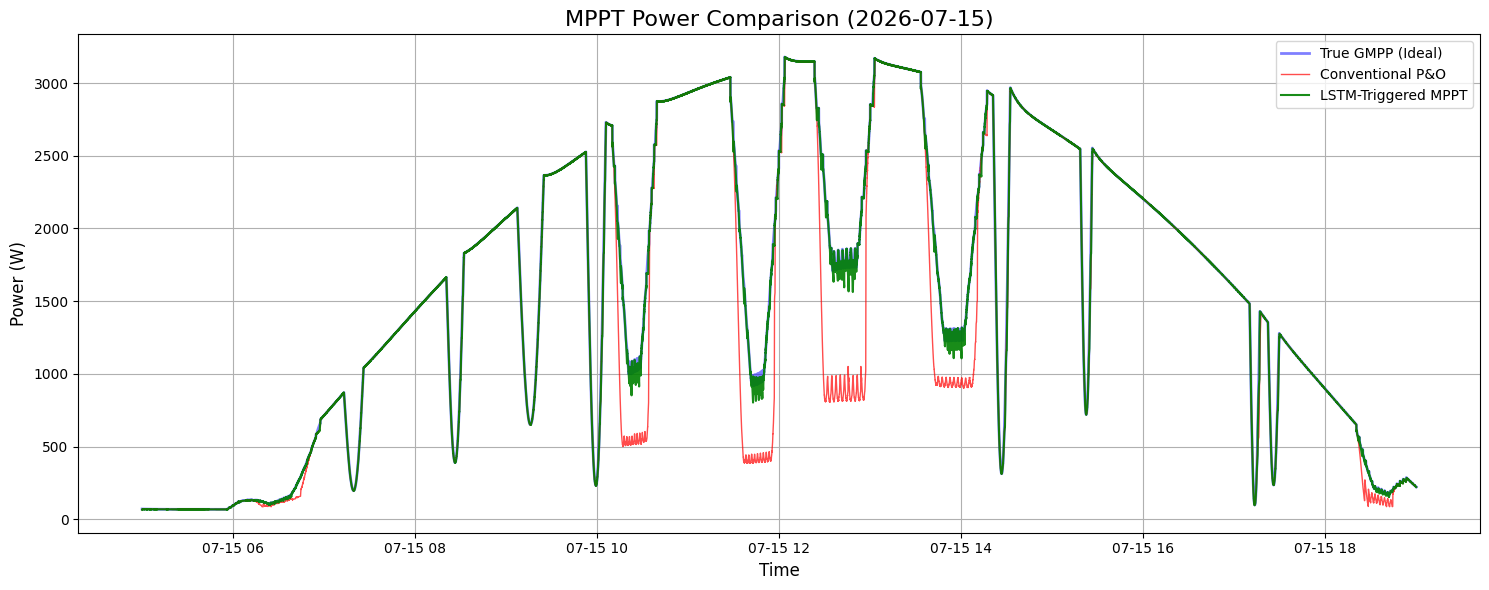

In [14]:
# =========================================================
# 실행 방법 (수정됨)
# =========================================================
target_date = "2026-07-15"

# GPU가 없으면 자동으로 'cpu'가 할당됨
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MPPTTriggerLSTM().to(device)

# [수정된 부분] map_location=device 파라미터 추가!
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/mppt_dataset/mppt_lstm_model.pth',
    map_location=device
))

run_mppt_comparison(target_date, model, scaler, device=device)

In [15]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm


def run_mppt_comparison(target_date, model, scaler, device='cpu', trigger_threshold=0.5):
    print(f"\n[{target_date}] MPPT 알고리즘 성능 비교 시뮬레이션 시작...")
    model.eval() # 모델을 평가 모드로 전환

    # =========================================================
    # 1. 환경 생성 (기존 simulate_single_day와 동일)
    # =========================================================
    start_time = f'{target_date} {START_HOUR:02d}:00:00'
    end_time = f'{target_date} {END_HOUR:02d}:00:00'
    times = pd.date_range(start=start_time, end=end_time, freq='s', tz=TZ)
    total_seconds = len(times)

    clearsky = site_location.get_clearsky(times)
    base_g_array = clearsky['ghi'].values

    G_matrix = np.zeros((total_seconds, NUM_MODULES))
    cloud = CloudEvent()
    cloud_type_array = np.zeros(total_seconds, dtype=int)

    for t in range(total_seconds):
        base_g = max(base_g_array[t], 20.0)
        if not cloud.active and np.random.rand() < (30 / total_seconds):
            cloud.trigger(t)
        factors = cloud.get_shading_factors(t)
        G_matrix[t, :] = base_g * factors

        if cloud.active:
            if cloud.event_type == 'moving':
                cloud_type_array[t] = 1
            elif cloud.event_type == 'uniform':
                cloud_type_array[t] = 2

    # 온도 계산
    T_matrix = np.zeros((total_seconds, NUM_MODULES))
    month = times[0].month
    temp_air_base = 15.0 - 15.0 * np.cos(np.pi * (month - 1) / 6.0)
    hours = times.hour + (times.minute / 60.0) + (times.second / 3600.0)
    temp_air_hourly = temp_air_base + 5.0 * np.sin(np.pi * (hours - 7.0) / 12.0)
    temp_air_series = pd.Series(temp_air_hourly, index=times)
    wind_speed_series = pd.Series(1.0, index=times)

    for i in range(NUM_MODULES):
        poa_series = pd.Series(G_matrix[:, i], index=times)
        t_cell = pvlib.temperature.fuentes(
            poa_global=poa_series, temp_air=temp_air_series,
            wind_speed=wind_speed_series, noct_installed=NOCT_INSTALLED
        )
        T_matrix[:, i] = t_cell.values

    # =========================================================
    # 2. 물리 엔진 사전 계산 (속도 최적화를 위해 한 번만 계산)
    # =========================================================
    true_v_arr = np.zeros(total_seconds)
    true_p_arr = np.zeros(total_seconds)
    v_clean_list = []
    i_clean_list = []

    for t in tqdm(range(total_seconds), desc="Physics Engine Pre-computing"):
        current_gs = G_matrix[t]
        current_ts = T_matrix[t]
        i_array = np.linspace(0, MODULE_DATA['I_sc_ref'] + 1, 300)
        v_total = np.zeros_like(i_array)

        for g, temp in zip(current_gs, current_ts):
            if g < 10: g = 10
            IL, Io, Rs, Rsh, nNsVth = pvlib.pvsystem.calcparams_desoto(
                effective_irradiance=g, temp_cell=temp,
                alpha_sc=MODULE_DATA['alpha_sc'], a_ref=MODULE_DATA['a_ref'],
                I_L_ref=MODULE_DATA['I_L_ref'], I_o_ref=MODULE_DATA['I_o_ref'],
                R_sh_ref=MODULE_DATA['R_sh_ref'], R_s=MODULE_DATA['R_s'],
                EgRef=1.121, dEgdT=-0.0002677
            )
            v_mod = pvlib.pvsystem.v_from_i(
                resistance_shunt=Rsh, resistance_series=Rs, nNsVth=nNsVth,
                saturation_current=Io, photocurrent=IL, current=i_array
            )
            v_total += np.maximum(v_mod, -0.7)

        p_total = v_total * i_array
        valid = p_total > 0
        p_clean, v_clean, i_clean = p_total[valid], v_total[valid], i_array[valid]

        idx_sort = np.argsort(v_clean)
        v_clean_sorted = v_clean[idx_sort]
        i_clean_sorted = i_clean[idx_sort]

        gmpp_idx = np.argmax(p_clean)
        true_v_arr[t] = v_clean[gmpp_idx]
        true_p_arr[t] = p_clean[gmpp_idx]

        v_clean_list.append(v_clean_sorted)
        i_clean_list.append(i_clean_sorted)

    # =========================================================
    # 3. 시나리오 A: 기존 P&O 시뮬레이션
    # =========================================================
    power_po = np.zeros(total_seconds)
    v_now = MODULE_DATA['V_oc_ref'] * NUM_MODULES * 0.8
    v_old, p_old = v_now, 0
    direction = 1

    for t in tqdm(range(total_seconds), desc="Scenario A: Conventional P&O"):
        v_clean_sorted, i_clean_sorted = v_clean_list[t], i_clean_list[t]
        i_measured = np.interp(v_now, v_clean_sorted, i_clean_sorted)
        p_measured = v_now * i_measured
        power_po[t] = p_measured

        if p_measured < p_old: direction *= -1
        v_old, p_old = v_now, p_measured
        v_now = np.clip(v_now + direction * 2.0, 10, v_clean_sorted[-1] if len(v_clean_sorted)>0 else 400)

    # =========================================================
    # 4. 시나리오 B: 제안하는 LSTM-Triggered MPPT 시뮬레이션
    # =========================================================
    power_lstm = np.zeros(total_seconds)
    v_now = MODULE_DATA['V_oc_ref'] * NUM_MODULES * 0.8
    v_old, p_old = v_now, 0
    direction = 1
    history = []
    trigger_count = 0

    for t in tqdm(range(total_seconds), desc="Scenario B: LSTM-Triggered MPPT"):
        v_clean_sorted, i_clean_sorted = v_clean_list[t], i_clean_list[t]
        i_measured = np.interp(v_now, v_clean_sorted, i_clean_sorted)
        p_measured = v_now * i_measured
        power_lstm[t] = p_measured

        # 1. dP/dV 계산
        dv = v_now - v_old
        dp_dv = 0.0 if (t == 0 or abs(dv) < 1e-4) else (p_measured - p_old) / dv

        # 2. History 버퍼 업데이트
        current_time = times[t]
        day_of_year = current_time.dayofyear
        hour_of_day = current_time.hour + (current_time.minute / 60.0)
        history.append([v_old, i_measured, p_measured, dp_dv, day_of_year, hour_of_day])

        if len(history) > WINDOW_SIZE:
            history.pop(0)

        # 3. LSTM Trigger 판단
        triggered = False
        if len(history) == WINDOW_SIZE:
            # 실시간 데이터 전처리 (스케일링 및 삼각함수 인코딩)
            hist_arr = np.array(history)
            scaled_features = scaler.transform(hist_arr[:, :4])
            scaled_day = np.sin(np.pi * hist_arr[:, 4] / 365.0)
            scaled_hour = np.cos(np.pi * (hist_arr[:, 5] - 5.0) / 14.0)

            X_input = np.zeros((1, WINDOW_SIZE, 6), dtype=np.float32)
            X_input[0, :, :4] = scaled_features
            X_input[0, :, 4] = scaled_day
            X_input[0, :, 5] = scaled_hour

            X_tensor = torch.tensor(X_input).to(device)

            # 모델 추론
            with torch.no_grad():
                logits = model(X_tensor)
                prob = torch.sigmoid(logits).item()

            # 트리거 발동 조건!
            if prob >= trigger_threshold:
                triggered = True
                trigger_count += 1

                # Global Scan 완료로 간주하고 v_now를 진짜 최적 전압으로 강제 점프
                v_now = true_v_arr[t]

                # 점프 후의 측정값으로 과거 값 즉시 업데이트 (다음 스텝 오류 방지)
                p_measured_jump = v_now * np.interp(v_now, v_clean_sorted, i_clean_sorted)
                v_old, p_old = v_now, p_measured_jump

                direction = 1 # 방향 초기화
                history.clear() # 갇힌 기억 삭제 (쿨다운)

        # 4. 트리거되지 않았을 때는 일반 P&O 수행
        if not triggered:
            if p_measured < p_old: direction *= -1
            v_old, p_old = v_now, p_measured
            v_now = np.clip(v_now + direction * 2.0, 10, v_clean_sorted[-1] if len(v_clean_sorted)>0 else 400)

    # =========================================================
    # 5. 발전량 계산 및 시각화 결과 출력
    # =========================================================
    # 1초 단위 전력(W) 합산 -> Ws -> 3600으로 나누어 Wh 변환
    energy_gmpp = np.sum(true_p_arr) / 3600
    energy_po = np.sum(power_po) / 3600
    energy_lstm = np.sum(power_lstm) / 3600

    print("="*50)
    print(f"[{target_date}] 시뮬레이션 결과 요약 (14시간 발전량)")
    print("="*50)
    print(f"1. 이상적인 최대 발전량 (True GMPP) : {energy_gmpp:.2f} Wh")
    print(f"2. 기존 P&O 발전량               : {energy_po:.2f} Wh (효율: {energy_po/energy_gmpp*100:.2f}%)")
    print(f"3. LSTM-Triggered P&O 발전량     : {energy_lstm:.2f} Wh (효율: {energy_lstm/energy_gmpp*100:.2f}%)")
    print(f"   => LSTM 모델이 총 {trigger_count}회 갇힘을 감지하여 구출함.")
    print(f"   => 기존 P&O 대비 추가 획득 전력: {energy_lstm - energy_po:.2f} Wh")
    print("="*50)

    # ---------------------------------------------------------
    # [수정된 부분] 1시간 단위로 그래프 분할 출력
    # ---------------------------------------------------------
    for h in range(START_HOUR, END_HOUR):
        # 현재 시간(h)에 해당하는 데이터만 필터링하기 위한 마스크
        mask = (times.hour == h)

        # 해당 시간에 데이터가 없으면 패스
        if not np.any(mask):
            continue

        time_slice = times[mask]
        true_p_slice = true_p_arr[mask]
        power_po_slice = power_po[mask]
        power_lstm_slice = power_lstm[mask]

        plt.figure(figsize=(15, 4)) # 높이를 4로 줄여서 여러 개가 나와도 보기 편하게 조정
        plt.plot(time_slice, true_p_slice, label='True GMPP (Ideal)', color='blue', alpha=0.5, linewidth=2)
        plt.plot(time_slice, power_po_slice, label='Conventional P&O', color='red', alpha=0.7, linewidth=1.5)
        plt.plot(time_slice, power_lstm_slice, label='LSTM-Triggered MPPT', color='green', alpha=0.9, linewidth=1.5)

        plt.title(f"MPPT Power Comparison ({target_date} {h:02d}:00 ~ {h+1:02d}:00)", fontsize=14)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Power (W)", fontsize=12)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# =========================================================
# 실행 방법 (예시)
# =========================================================
# target_date = "2026-07-15"
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = MPPTTriggerLSTM().to(device)
# model.load_state_dict(torch.load('best_model.pth')) # 학습된 가중치 로드
# # scaler = joblib.load('scaler.pkl') # 전처리 과정에서 저장한 scaler 객체 로드
#
# run_mppt_comparison(target_date, model, scaler, device=device)


[2026-07-15] MPPT 알고리즘 성능 비교 시뮬레이션 시작...


Scenario B: LSTM-Triggered MPPT: 100%|██████████| 50401/50401 [00:57<00:00, 879.27it/s]


[2026-07-15] 시뮬레이션 결과 요약 (14시간 발전량)
1. 이상적인 최대 발전량 (True GMPP) : 21611.65 Wh
2. 기존 P&O 발전량               : 19825.31 Wh (효율: 91.73%)
3. LSTM-Triggered P&O 발전량     : 21496.10 Wh (효율: 99.47%)
   => LSTM 모델이 총 307회 갇힘을 감지하여 구출함.
   => 기존 P&O 대비 추가 획득 전력: 1670.79 Wh


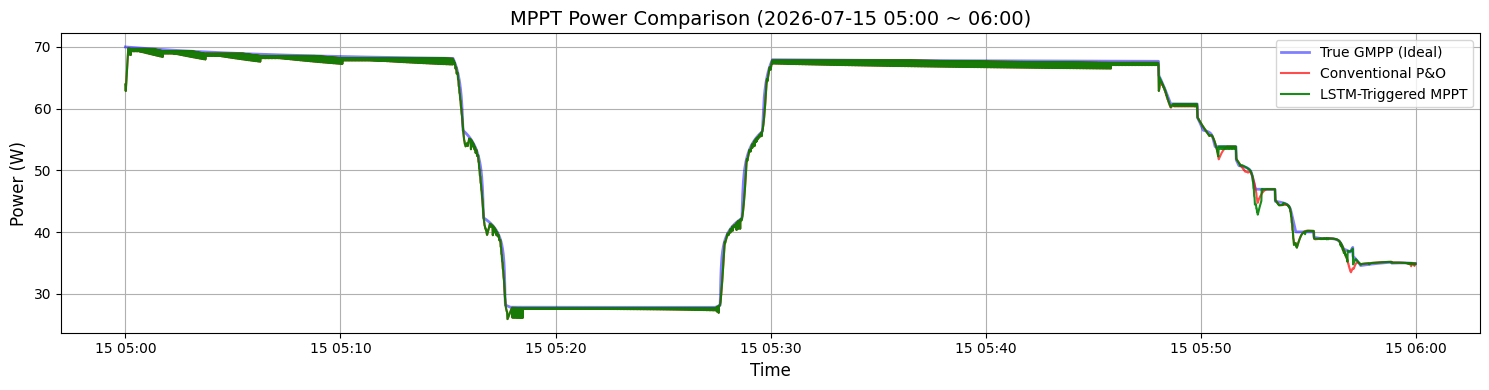

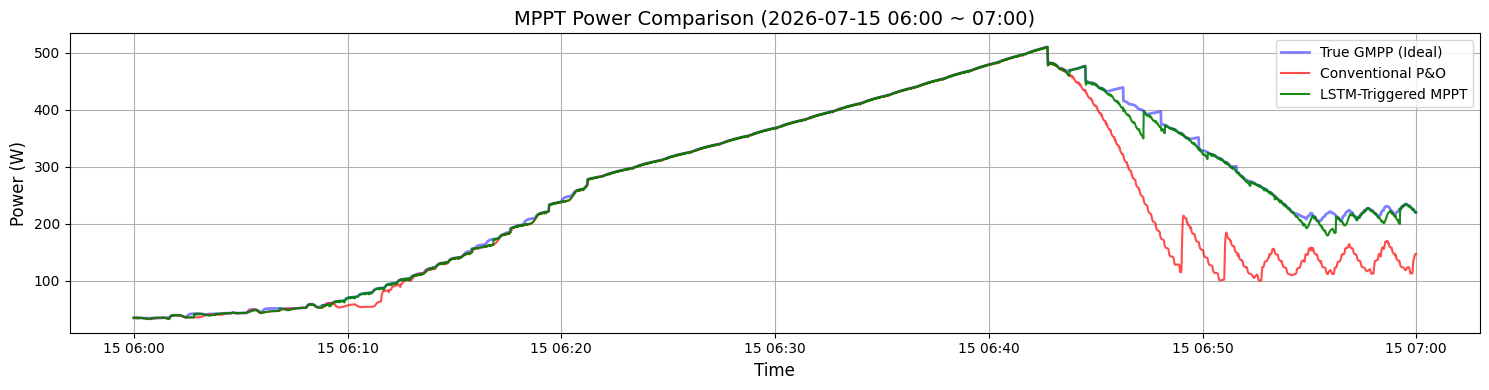

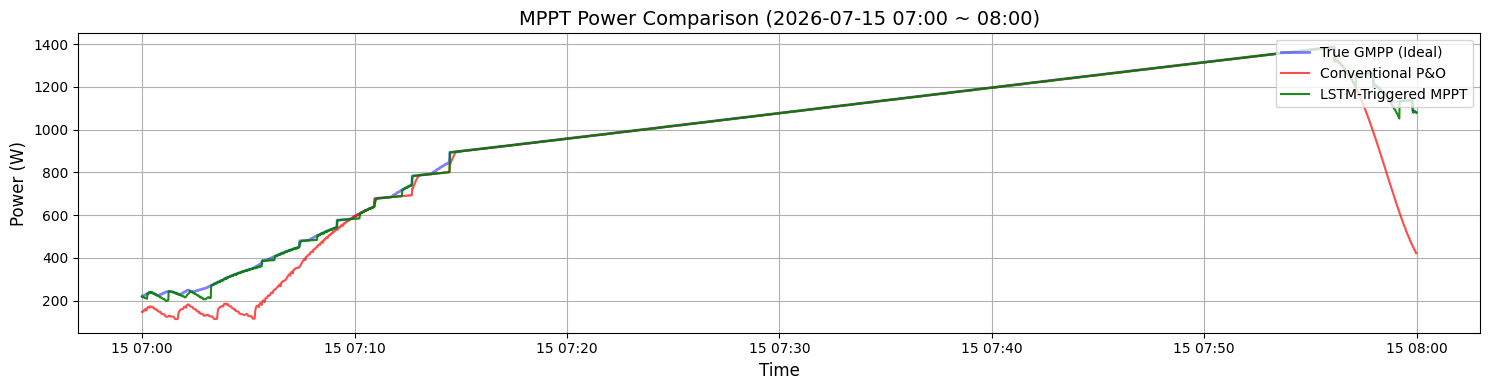

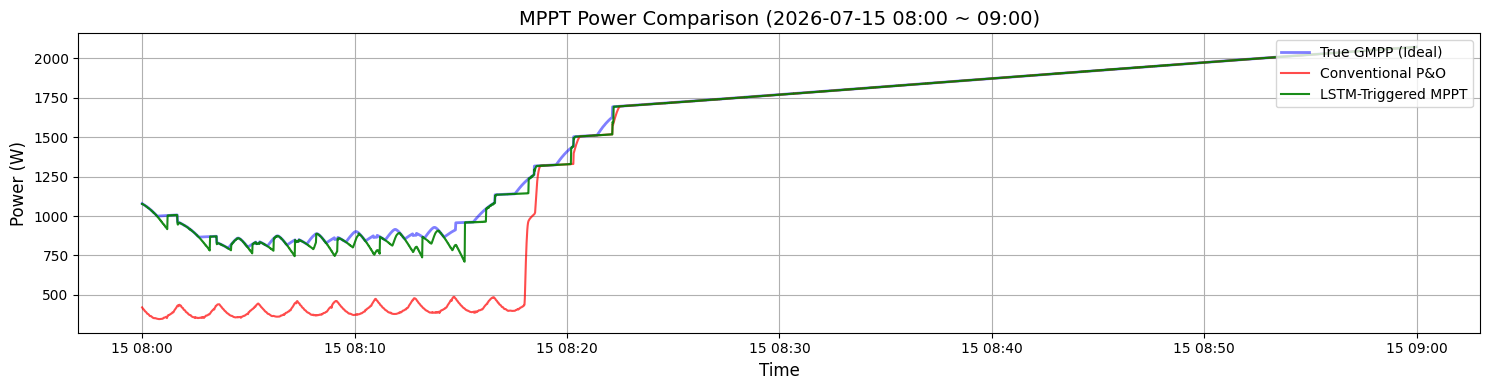

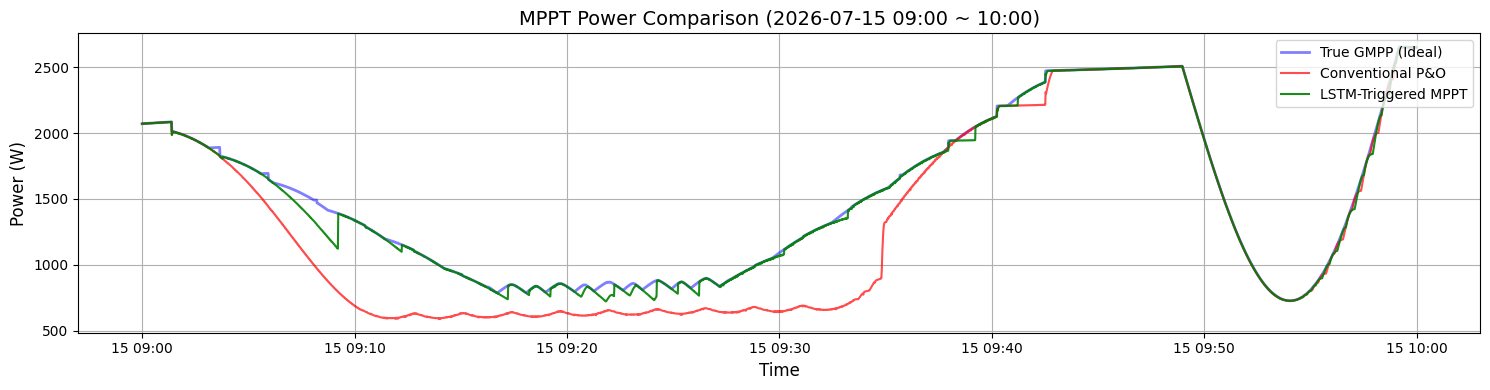

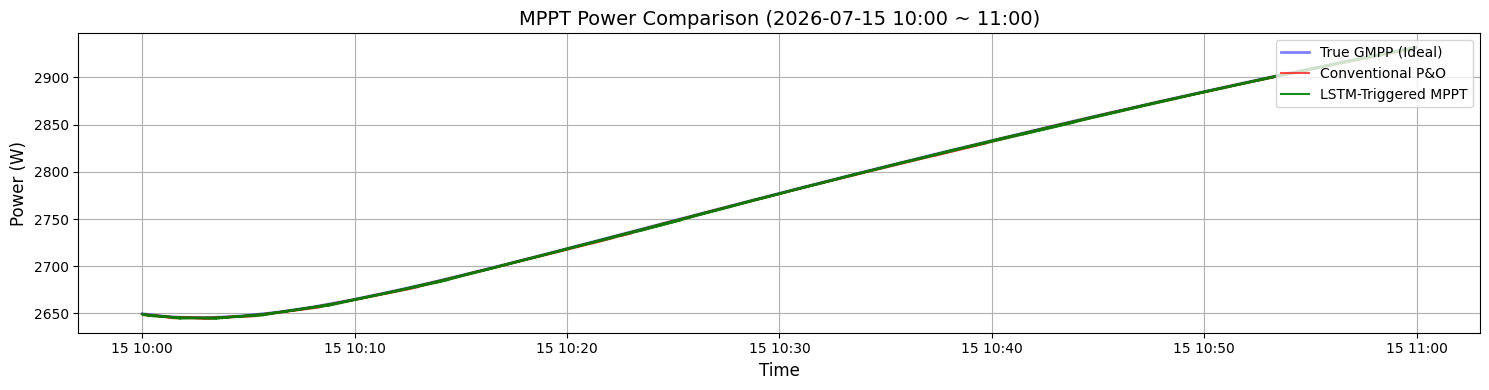

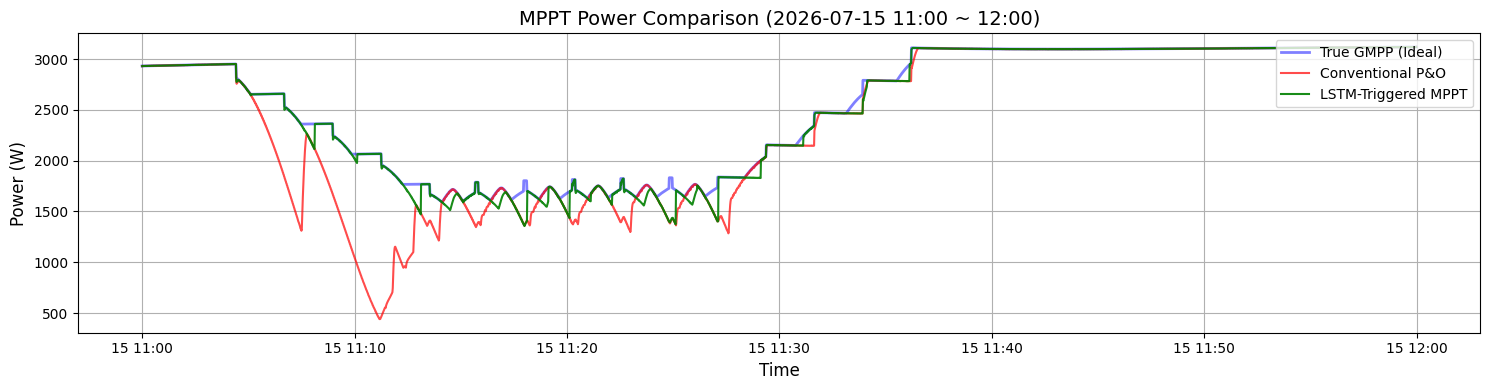

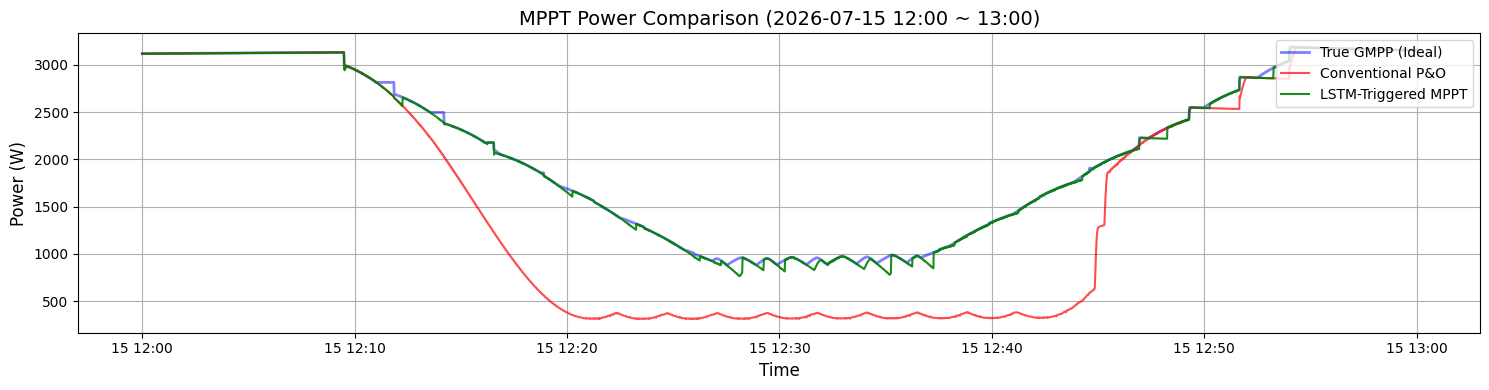

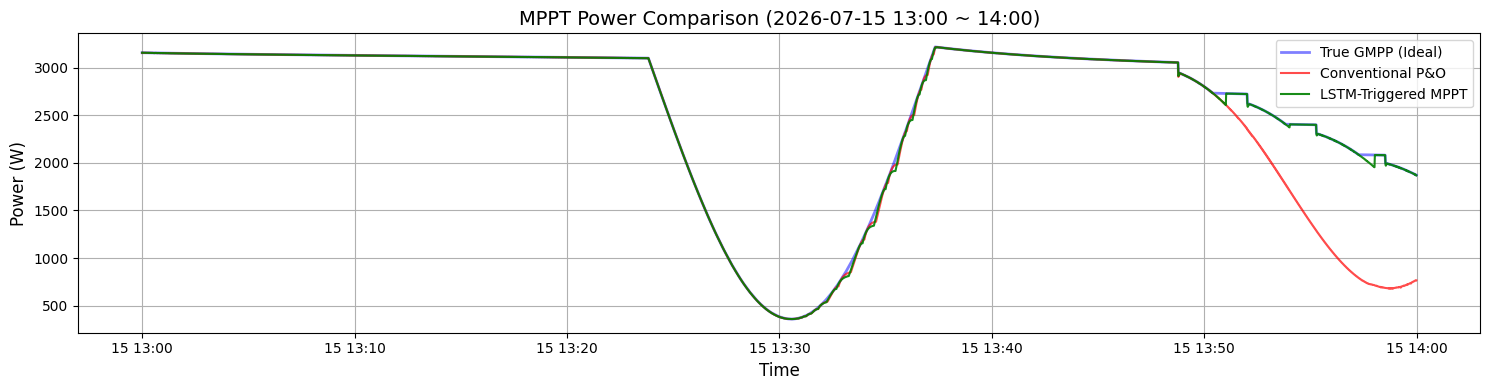

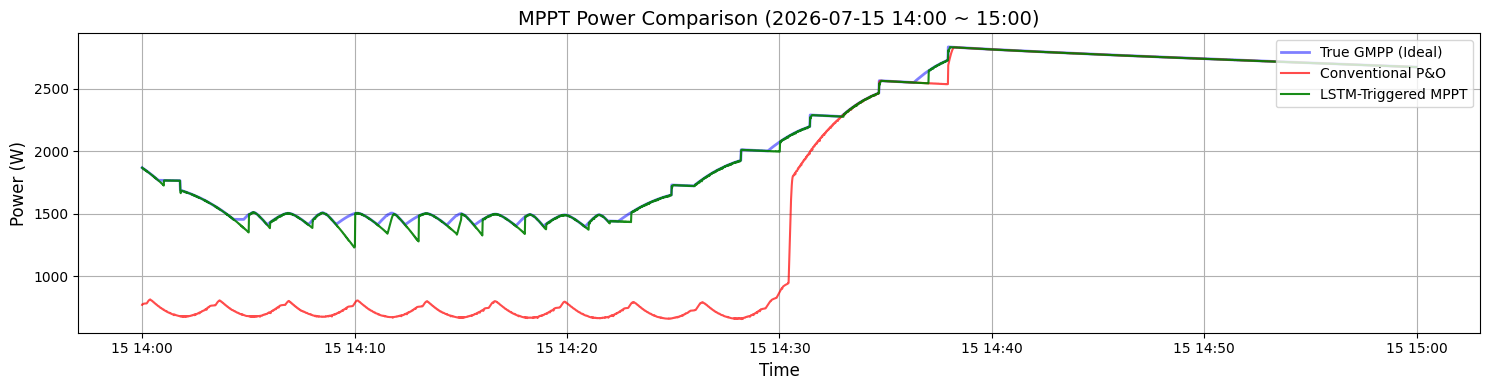

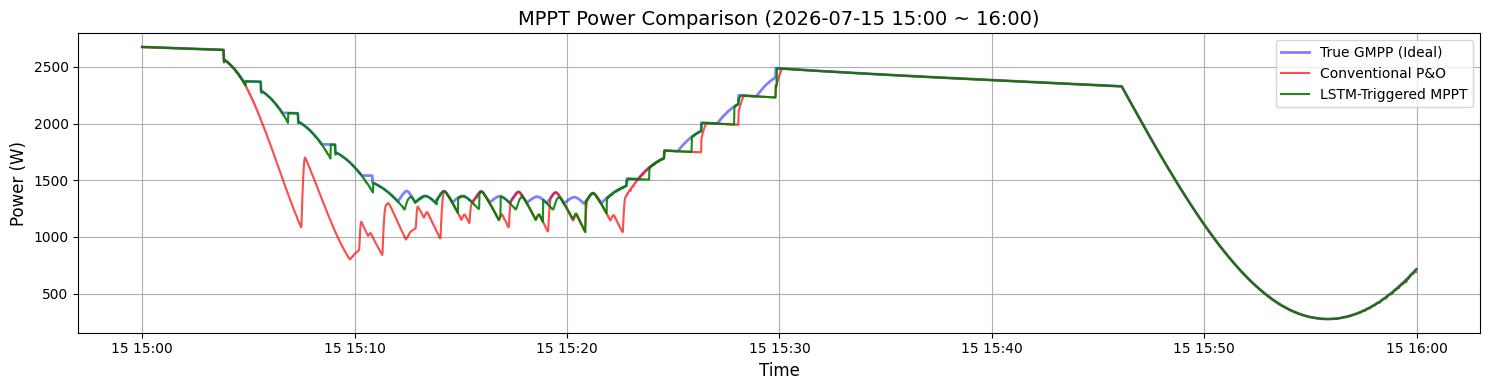

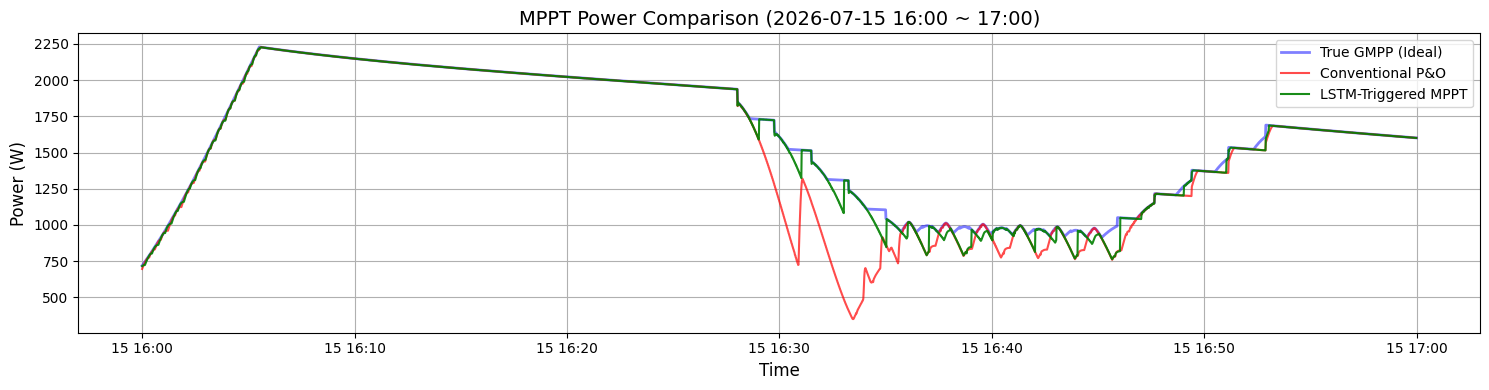

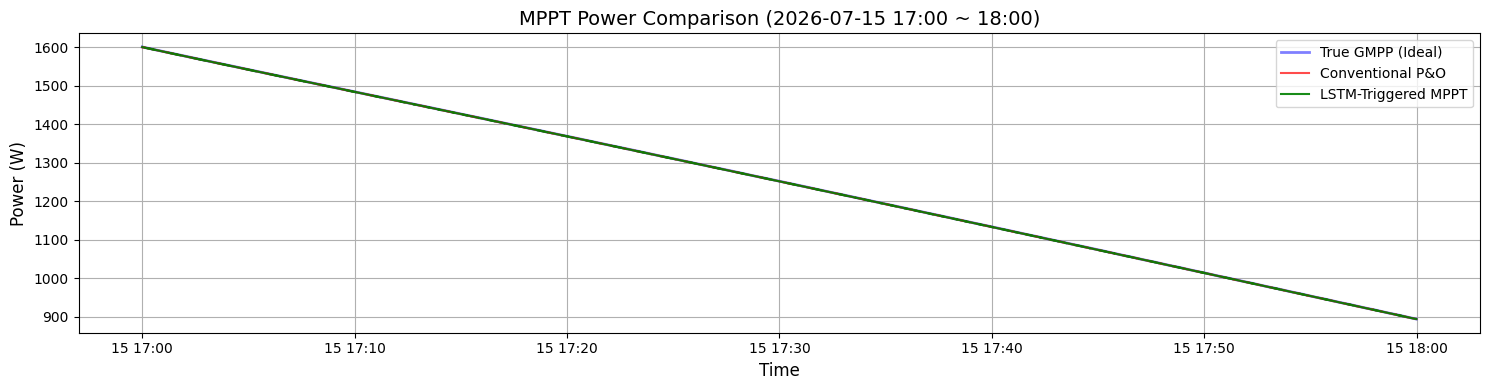

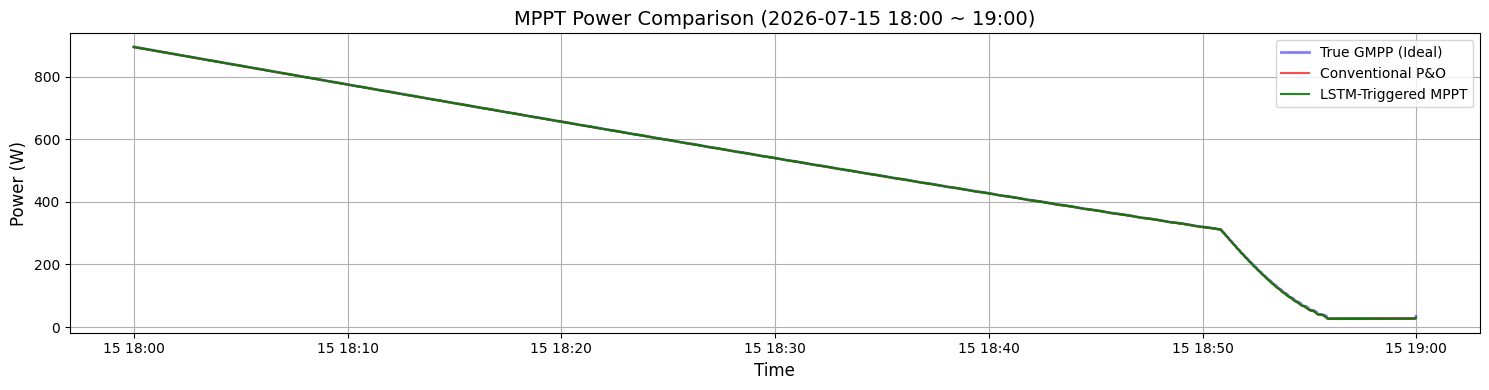

In [16]:
# =========================================================
# 실행 방법 (수정됨)
# =========================================================
target_date = "2026-07-15"

# GPU가 없으면 자동으로 'cpu'가 할당됨
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MPPTTriggerLSTM().to(device)

# [수정된 부분] map_location=device 파라미터 추가!
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/mppt_dataset/mppt_lstm_model.pth',
    map_location=device
))

run_mppt_comparison(target_date, model, scaler, device=device)